### Computing max average reward rates theoretically

Given an agent with a policy to gather $(k_1, \, k_2, \,k_3, \,...)$ rewards from an environment in which the reward function is

$$
    p(r=1 | R) = a e^{-R/\tau},
$$

where R is the sum of rewards within a patch, we would like to compute the expected return of the agent for a set of $\left(\tau_1, \tau_2, \tau_3\right)$ and a fixed $a$.

The expected reward for an environment with a single patch with reward curve parametrized by $\tau$ when the agent will gather $k$ rewards is

$$
    \mathbb{E}[r|k, \, \tau] = \frac{k}{T_{\rm intersite} + n(k, \, \tau) (T_{\rm harvest} + T_{\rm intersite}) + T_{\rm leave} + T_{\rm interpatch}},
$$

where $n(k, \, \tau)$ is the expected number of stops required to harvest $k$ rewards.

In an environment with multiple patch types and a policy of stopping $n_i$ times for each, this becomes

$$
    \mathbb{E}[r|k, \, \tau] = \frac{\sum_i k_i}{ \sum_i T_{\rm intersite} + n(k_i, \, \tau_i) (T_{\rm harvest} + T_{\rm intersite}) + T_{\rm leave} + T_{\rm interpatch}},
$$

We can first compute the probability of stopping n' times given the agent must collect k rewards and currently has collected R rewards,

$$
    p(n = n'| k, R),
$$

which obeys the recurrence relation

$$
    p(n = n'| k, R) = p(r=1| R) \, p(n = n'- 1| k-1, R+1) + p(r=0| R) \, p(n = n'- 1| k, R).
$$

We also know that if $k > n'$, then the associated probability is zero. If $k = 0$ and $n' > 0$, then the probability is also zero.

Once we have computed these probabilities, then

$$
    n(k, \, \tau) = \sum_{n'=k}^{\infty} p(n = n'| k, R) \, n'.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def p_k_additional_rewards_in_n_sites_given_i_rewards(k, n, i, cache, a, tau):
    if n == 0:
        return 0
    elif k == 0:
        return 0
    else:
        if k > n:
            p = 0
        elif k == n:
            p = p_k_consecutive_rewarded_sites_given_i_rewards(k, i, a, tau)
        elif cache[k, n, i] != -1:
            p = cache[k, n, i]
        else:
            # n - k fails allowed
            p =  rewarded_given_i_rewards(i, a, tau) * p_k_additional_rewards_in_n_sites_given_i_rewards(k-1, n-1, i+1, cache, a, tau) \
            + unrewarded_given_i_rewards(i, a, tau) * p_k_additional_rewards_in_n_sites_given_i_rewards(k, n-1, i, cache, a, tau)
        cache[k, n, i] = p
        return p

def p_k_consecutive_rewarded_sites_given_i_rewards(k, i, a, tau):
    return np.prod([rewarded_given_i_rewards(i + r, a, tau) for r in np.arange(k)])

def rewarded_given_i_rewards(i, a, tau):
    return a * np.exp(-i/tau)

def unrewarded_given_i_rewards(i, a, tau):
    return 1 - rewarded_given_i_rewards(i, a, tau)

def expected_stops_given_tau_and_k_rewards(k, a, tau):
    exp_stops = 0
    max_stop_iter = 500
    cache = np.ones((k+1, max_stop_iter, k+1)) * -1
    probs = []
    for n in range(500):
        p_n_stops = p_k_additional_rewards_in_n_sites_given_i_rewards(k, n, 0, cache=cache, a=a, tau=tau)
        probs.append(p_n_stops)
        exp_stops += p_n_stops * n
    exp_stops += (1 - np.sum(probs)) * max_stop_iter
    return exp_stops, probs

(0.0, 100.0)

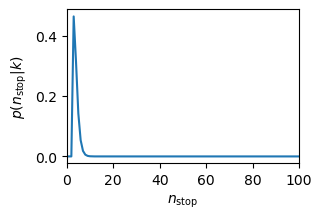

In [52]:
exp_stops, probs = expected_stops_given_tau_and_k_rewards(k=3, a=0.8, tau=30)

fig, axs = plt.subplots(1, 1, figsize=(3, 2))
axs.plot(np.arange(len(probs)), probs)
axs.set_ylabel(r'$p(n_{\rm stop} | k)$')
axs.set_xlabel(r'$n_{\rm stop} $')
axs.set_xlim(0, 100)

7.710321476816362


(0.0, 30.0)

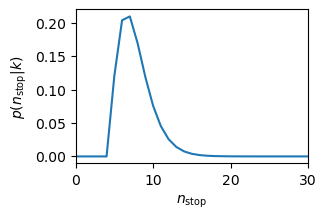

In [53]:
exp_stops, probs = expected_stops_given_tau_and_k_rewards(k=5, a=0.8, tau=10)
print(exp_stops)

fig, axs = plt.subplots(1, 1, figsize=(3, 2))
axs.plot(np.arange(len(probs)), probs)
axs.set_ylabel(r'$p(n_{\rm stop} | k)$')
axs.set_xlabel(r'$n_{\rm stop} $')
axs.set_xlim(0, 30)

20.002524290594216


(0.0, 30.0)

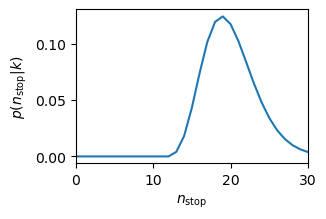

In [54]:
exp_stops, probs = expected_stops_given_tau_and_k_rewards(k=13, a=0.8, tau=30)
print(exp_stops)

fig, axs = plt.subplots(1, 1, figsize=(3, 2))
axs.plot(np.arange(len(probs)), probs)
axs.set_ylabel(r'$p(n_{\rm stop} | k)$')
axs.set_xlabel(r'$n_{\rm stop} $')
axs.set_xlim(0, 30)

Given the agent must stop to collect $k$ rewards, here is an example of the probability dist. of stopping exactly $n$ times.

In [4]:
def expected_reward_rate_for_env_and_policy(taus, amps, k_rewards_by_tau, d_site_stop, d_site_run, d_intersite, interpatch):
    total_reward = np.sum(k_rewards_by_tau)
    denom = 0
    for tau, a, k in zip(taus, amps, k_rewards_by_tau):
        if k == 0:
            expected_n = 0
        else:
            expected_n, probs = expected_stops_given_tau_and_k_rewards(k=k, a=a, tau=tau)
        denom += (d_intersite + expected_n * (d_site_stop + d_intersite) + d_site_run)
    denom += interpatch * len(taus)
    return total_reward / denom


What is the theoretical maximum for the patch foraging task when

$$
    a_2 = a_3 = 0.8 \
$$
$$
    a_1 = 0 \
$$
$$
    \tau_2 = 10 \
$$
$$
    \tau_3 = 30
$$

In [5]:
taus = [1e-8, 10., 30.]
amps = [0.8, 0.8, 0.8]

max_policy = None
max_rate = 0
for k_2 in range(15):
    for k_3 in range(15):
        policy_rate = expected_reward_rate_for_env_and_policy(
            taus=taus,
            amps=amps,
            k_rewards_by_tau=[0, k_2, k_3],
            d_site_stop=7,
            d_site_run=3,
            d_intersite=2.15,
            interpatch=5.5,
        )
        if policy_rate > max_rate:
            max_rate = policy_rate
            max_policy = (k_2, k_3)

print('Max policy', max_policy)
print('Max rate', max_rate)
print('Leave rates', [rewarded_given_i_rewards(i-1, 0.8, tau) for (i, tau) in zip(max_policy, taus[1:])])

Max policy (4, 10)
Max rate 0.06394698026832753
Leave rates [0.5926545765453743, 0.5926545765453743]


Model predicts a max reward rate of ~0.0725, which roughly agrees with the best performance simulated agents achieve.

What if intersite distribution, which is usually a truncated exponential, is flipped?

In [24]:
max_policy = None
max_rate = 0
for k_2 in range(15):
    for k_3 in range(15):
        policy_rate = expected_reward_rate_for_env_and_policy(
            taus=[1e-8, 10, 30],
            amps=[1e-8, 0.8, 0.8],
            k_rewards_by_tau=[0, k_2, k_3],
            d_site_stop=6,
            d_site_run=3,
            d_intersite=6 - 2.15, # consider flipped distribution mean
            interpatch=5.5,
        )
        if policy_rate > max_rate:
            max_rate = policy_rate
            max_policy = (k_2, k_3)

print('Max policy', max_policy)
print('Max rate', max_rate)

Max policy (4, 10)
Max rate 0.058740612415832574


#### Computing the average time spent running through intersite and interpatch intervals drawn from truncated exponential distributions

In [12]:
interreward_len_bounds = np.array([1.0, 6.0])
interreward_len_decay_rate = 0.8
interpatch_len_bounds = np.array([1.0, 12.0])
interpatch_len_decay_rate = 0.1

In [13]:
from jax import numpy as jnp
from jax import random as random

def sample_truncated_exp(
    key: jnp.ndarray, 
    bounds: jnp.ndarray, 
    decay_rate: float
) -> jnp.ndarray:
    """Sample from truncated exponential distribution
    
    Args:
        key: Random key
        bounds: [min_val, max_val] bounds for truncation
        decay_rate: Exponential decay rate parameter
    
    Returns:
        Sample from truncated exponential
    """
    min_val, max_val = bounds[0], bounds[1]
    
    # Sample from uniform [0, 1)
    u = random.uniform(key)
    
    # Convert to truncated exponential using inverse CDF
    # F(x) = (1 - exp(-decay_rate * x)) / (1 - exp(-decay_rate * (max_val - min_val)))
    # for x in [0, max_val - min_val], then shift by min_val

    exp_max = jnp.exp(-decay_rate * (max_val - min_val))
    sample = -jnp.log(1 - u * (1 - exp_max)) / decay_rate
    
    return min_val + sample

In [43]:
import jax
key = random.PRNGKey(51)
keys = random.split(key, 10000)
samples = jax.vmap(sample_truncated_exp, in_axes=(0, None, None))(keys, interreward_len_bounds, interreward_len_decay_rate)
mean_interward = jnp.mean(samples)
print('Mean interreward site distance:', mean_interward)

Mean interreward site distance: 2.1643121


In [44]:
key = random.PRNGKey(101)
key, subkey = random.split(key)
keys = random.split(subkey, 10000)
samples = jax.vmap(sample_truncated_exp, in_axes=(0, None, None))(keys, interpatch_len_bounds, interpatch_len_decay_rate)
mean_interpatch = jnp.mean(samples)
print('Mean interpatch distance:', mean_interpatch)

Mean interpatch distance: 5.5706096


#### What is the optimal reward rate for a series of environments where the reward parameters are drawn from a uniform distribution?

In [12]:
def find_max_policy_for_env(taus, amps):
    max_policy = None
    max_rate = 0
    for k_1 in range(10):
        for k_2 in range(10):
            for k_3 in range(10):
                policy_rate = expected_reward_rate_for_env_and_policy(
                    taus=taus,
                    amps=amps,
                    k_rewards_by_tau=(k_1, k_2, k_3),
                    d_site_stop=6,
                    d_site_run=3,
                    d_intersite=2.25,
                    interpatch=5.28,
                )
                if policy_rate > max_rate:
                    max_rate = policy_rate
                    max_policy = (k_1, k_2, k_3)
    
    # print('Max policy', max_policy)
    # print('Max rate', max_rate)
    return max_rate, max_policy
    

In [13]:
rates = np.zeros((50))
for i in range(50):
    taus = np.random.rand(3) * 50 + 1e-8 # draw taus independently from uniform distribution
    amps = np.ones((3)) * 0.8
    rate, policy = find_max_policy_for_env(taus, amps) # find max reward rate and policy for environment
    rates[i] = rate
    print(taus)
    print(policy)
    print(rate)
np.mean(rates)

[41.97589186  5.07452273 10.07960175]
(9, 2, 3)
0.07597427008989532
[49.5435157   9.51073837 37.51975787]
(9, 2, 8)
0.07979938687285094
[48.63925327 24.99642275 21.19844131]
(9, 5, 5)
0.07966882584277786
[45.37445669  2.71627788 45.069706  ]
(9, 1, 9)
0.07973965003110742
[16.87443427 39.59956208 41.71921206]
(4, 8, 9)
0.07995554495610867
[36.55680707 21.18387683  3.77942414]
(9, 5, 1)
0.07662856149802955
[34.12484313 43.66360955 35.64388679]
(7, 8, 7)
0.08089579691084799



KeyboardInterrupt



In [26]:
rate, policy = find_max_policy_for_env([30, 10, 1], [0.8, 0.8, 0])
print(rate)
print(policy)

0.07246861600161958
(9, 3, 0)


In [27]:
rate, policy = find_max_policy_for_env([40, 30, 20], [0.8, 0.8, 0.8])
print(rate)
print(policy)

0.07933138881868473
(9, 7, 5)


In [28]:
rate, policy = find_max_policy_for_env([20, 10, 1], [0.8, 0.8, 0])
print(rate)
print(policy)

0.06990536933767623
(7, 4, 0)


In [23]:
rates = np.zeros((50))
for i in range(50):
    taus = (np.random.rand(3) * 40 + 1e-8)
    amps = np.ones((3)) * 0.8
    rate, policy = find_max_policy_for_env(taus, amps)
    rates[i] = rate
    print(taus)
    print(policy)
    print(rate)
np.mean(rates)

[28.09300734 26.72876501 30.34339927]
(6, 6, 7)
0.07898841565809529
[11.02659889 30.62589741 27.67175519]
(3, 7, 7)
0.07753432398919607
[16.08520953 18.04371639 38.49214439]
(4, 4, 9)
0.07785623795972077
[ 4.7691372  35.03753066 15.60580635]
(2, 9, 4)
0.07586541337163728
[36.68880592  6.08343239 16.47352708]
(9, 2, 4)
0.07639262738951486
[17.9275026   2.88478927 24.76531368]
(5, 1, 7)
0.07440060869924581
[ 3.13575415 24.69722956 38.80243526]
(1, 6, 9)
0.07733155029567121
[10.44764293 19.08974074 37.13397962]
(3, 5, 9)
0.07726481050388648
[33.33870512 10.88093281  6.62157658]
(9, 3, 2)
0.07522225729240516
[16.13377371 13.49200236 20.81617667]
(5, 4, 6)
0.07511385000294955
[13.50430397 24.61591875  5.92348128]
(4, 7, 2)
0.0741041323312857
[23.93723544 31.26321376  8.81926893]
(6, 8, 3)
0.07691494841477757
[11.18782991 31.38661189  0.78970635]
(3, 9, 1)
0.07434627577300938
[39.52203638 15.13756029 15.33142406]
(9, 4, 4)
0.07761167389674713
[34.04048019 36.29126189  6.72759552]
(8, 8, 2)
0

0.07632103405304835

In [29]:
rates = np.zeros((100))
for i in range(100):
    taus = (np.random.rand(3) * 40 + 1e-8)
    amps = np.ones((3)) * 0.8
    rate, policy = find_max_policy_for_env(taus, amps)
    rates[i] = rate
    print(taus)
    print(policy)
    print(rate)
np.mean(rates)

[18.00437531  5.04902359 16.2028992 ]
(6, 2, 5)
0.07315914393627596
[ 8.67326141  7.45126499 29.45390687]
(3, 2, 8)
0.07428167624205873
[ 7.84735473 18.19061345 18.92687127]
(3, 5, 6)
0.07415185212182386
[ 8.20162033  1.43376321 24.73985557]
(3, 1, 8)
0.07241102318012556
[16.83568117 28.40190227  9.06889816]
(5, 8, 3)
0.07567897586169535
[13.4945717  19.64778681 21.24944632]
(4, 5, 6)
0.07569685694759862
[32.02494279 17.80316026 10.2437576 ]
(8, 5, 3)
0.07648301379688063
[22.31319913 12.83510346 33.25776732]
(6, 3, 8)
0.07739977814640218
[13.45253467  6.14895231 26.56775639]
(4, 2, 8)
0.07445676715776424
[25.38140944  7.68706198 10.19732277]
(7, 3, 3)
0.07386100133140702
[ 1.99367624 19.22141081  0.50878278]
(1, 7, 1)
0.0690694924231923
[ 5.25020637 23.78475031  6.74142126]
(2, 7, 2)
0.07232831145487449
[22.44785536 16.16687377 12.60202772]
(6, 5, 4)
0.07521513708905235
[ 6.78851261 19.86803    12.13111818]
(2, 6, 4)
0.07298792280672645
[30.00687439 25.18739892 15.67457967]
(7, 6, 4)
0

0.07520833042450839

Try to compute optimal rate for setting where environment quality is drawn from a uniform distribution and then taus are drawn from a gamma distribution with shape parameter = environment quality:

In [20]:
rates = np.zeros((50))
for i in range(50):
    env_quality = np.random.rand(1) * 40
    taus = np.random.gamma(env_quality * np.ones(3)) + 1e-6
    amps = np.ones((3)) * 0.8
    rate, policy = find_max_policy_for_env(taus, amps)
    rates[i] = rate
    print(taus)
    print(policy)
    print(rate)
np.mean(rates)

[39.29156879 34.64375861 41.29911208]
(8, 7, 8)
0.08099651401821546
[2.34830881 5.80166446 4.24243129]
(2, 3, 2)
0.06282088871128468
[16.91966994 24.23915395 13.23436228]
(5, 7, 4)
0.07567961466519295
[43.17301669 50.9827978  35.83242238]
(8, 9, 7)
0.08175415461281746
[34.97620247 31.05023168 37.9464249 ]
(7, 6, 8)
0.08032990748454599
[24.81805195 20.45999237 18.58375415]
(6, 5, 5)
0.07691724411820287
[21.8237689  34.06063331 23.38585573]
(5, 8, 5)
0.07847435074063677
[29.50566618 33.83628082 35.76655343]
(6, 7, 7)
0.08001813024791497
[13.9076648  14.27691223  8.8195394 ]
(5, 5, 3)
0.0725877772770176
[24.53690098 29.0042398  29.37584266]
(6, 7, 7)
0.07877219844643207
[ 7.39768797 11.69062351  4.83355794]
(3, 4, 2)
0.06892396512232488
[34.45610549 51.00178079 39.4863858 ]
(6, 9, 7)
0.08149594131412183
[7.74115986 8.73991939 7.51982212]
(3, 3, 3)
0.06889935389864205
[36.47310167 32.79971007 35.01894083]
(7, 7, 7)
0.0803504266433508
[36.01794511 33.53607383 34.00612533]
(7, 7, 7)
0.080311

0.07535944930213312

In [19]:
rates = np.zeros((100))
for i in range(100):
    env_quality = np.random.rand(1) * 40
    taus = np.random.gamma(env_quality * np.ones(3)) + 1e-6
    amps = np.ones((3)) * 0.8
    rate, policy = find_max_policy_for_env(taus, amps)
    rates[i] = rate
    print(taus)
    print(rate)
np.mean(rates)

[6.28732604 6.11303735 4.98661434]
0.06606432268691306
[0.08044485 0.85769281 0.22021041]
0.05378512841199408
[23.52901547 26.34578155 15.76923731]
0.07711837004378527
[ 7.29937867  6.46870911 10.51894229]
0.06906958300235314
[24.02740471 19.0505631  15.95394159]
0.07632451012344112
[19.7665652  10.80643667 23.26694411]
0.07561345259597756
[21.52180336 18.46429614 23.57873581]
0.07686671161888022
[15.3318676  16.84701374 22.54006462]
0.07573886807563862
[ 5.09880291  5.50776167 13.87146789]
0.06909944341850192
[35.68236099 44.77499666 32.31413468]
0.08085786854551735
[23.66964506 26.28719637 16.30041056]
0.07717862798181303
[17.61550662 11.87154769 19.38474829]
0.0748250816385698
[32.37685016 38.17116213 38.37790527]
0.08061588322351187
[35.94278797 29.45576691 36.2681891 ]
0.08018161342494223
[9.80019301 5.16357425 7.57303913]
0.06840740101101599
[36.00266462 33.59591099 34.42443145]
0.08034115973231587
[27.58038762 32.19188554 23.26069798]
0.0788081351065954
[37.94514919 37.5981899  

0.0738987759910226